In [1]:
#decision tree 
#i)entropy= it measures the randomness (range is 0 to 1) 
#ii)information gain= parent entopy-child entropy (higher the ig best the model)
#iii)gini index= measures impurity (lower gini better split)

In [2]:
#single parameter = parameter tuning
#multiple parameter= hyper parameter tuning
#pruning= removal of nodes after finiding the accuracy with max depth
#cv= cross validation
#regression= voting
#classification= average/mean
#n_estimators= gives the no of decision trees working in random forest

In [28]:
#DECISION TREE CLASSIFIER

In [29]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report
from sklearn import tree

import matplotlib.pyplot as plt
import seaborn as sns

In [101]:
df=pd.read_csv('loan.csv')
df

,age,gender,marital_status,education_level,annual_income,monthly_income,employment_status,debt_to_income_ratio,credit_score,loan_amount,...,loan_term,installment,grade_subgrade,num_of_open_accounts,total_credit_limit,current_balance,delinquency_history,public_records,num_of_delinquencies,loan_paid_back
0,59,Male,Married,Master's,24240.19,2020.02,Employed,0.074,743,17173.72,...,36,581.88,B5,7,40833.47,24302.07,1,0,1,1
1,72,Female,Married,Bachelor's,20172.98,1681.08,Employed,0.219,531,22663.89,...,60,573.17,F1,5,27968.01,10803.01,1,0,3,1
2,49,Female,Single,High School,26181.80,2181.82,Employed,0.234,779,3631.36,...,60,76.32,B4,2,15502.25,4505.44,0,0,0,1
3,35,Female,Single,High School,11873.84,989.49,Employed,0.264,809,14939.23,...,36,468.07,A5,7,18157.79,5525.63,4,0,5,1
4,63,Other,Single,Other,25326.44,2110.54,Employed,0.260,663,16551.71,...,60,395.50,D5,1,17467.56,3593.91,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,39,Female,Married,Bachelor's,39640.08,3303.34,Employed,0.275,691,16322.23,...,36,566.22,C5,2,23748.10,5801.45,1,0,4,0
19996,66,Female,Married,Bachelor's,32062.90,2671.91,Employed,0.367,758,16697.34,...,36,553.71,B5,8,49929.65,40901.31,3,0,3,1
19997,65,Female,Single,Master's,18642.02,1553.50,Student,0.106,751,23924.78,...,36,772.66,B4,3,13137.57,5075.67,1,0,2,1
19998,35,Male,Married,Master's,22181.39,1848.45,Retired,0.275,646,16920.13,...,36,595.36,D2,5,19580.82,3876.16,4,0,5,1


In [102]:
df.head()

,age,gender,marital_status,education_level,annual_income,monthly_income,employment_status,debt_to_income_ratio,credit_score,loan_amount,...,loan_term,installment,grade_subgrade,num_of_open_accounts,total_credit_limit,current_balance,delinquency_history,public_records,num_of_delinquencies,loan_paid_back
0,59,Male,Married,Master's,24240.19,2020.02,Employed,0.074,743,17173.72,...,36,581.88,B5,7,40833.47,24302.07,1,0,1,1
1,72,Female,Married,Bachelor's,20172.98,1681.08,Employed,0.219,531,22663.89,...,60,573.17,F1,5,27968.01,10803.01,1,0,3,1
2,49,Female,Single,High School,26181.80,2181.82,Employed,0.234,779,3631.36,...,60,76.32,B4,2,15502.25,4505.44,0,0,0,1
3,35,Female,Single,High School,11873.84,989.49,Employed,0.264,809,14939.23,...,36,468.07,A5,7,18157.79,5525.63,4,0,5,1
4,63,Other,Single,Other,25326.44,2110.54,Employed,0.260,663,16551.71,...,60,395.50,D5,1,17467.56,3593.91,2,0,2,1


In [103]:
df.tail()

,age,gender,marital_status,education_level,annual_income,monthly_income,employment_status,debt_to_income_ratio,credit_score,loan_amount,...,loan_term,installment,grade_subgrade,num_of_open_accounts,total_credit_limit,current_balance,delinquency_history,public_records,num_of_delinquencies,loan_paid_back
19995,39,Female,Married,Bachelor's,39640.08,3303.34,Employed,0.275,691,16322.23,...,36,566.22,C5,2,23748.10,5801.45,1,0,4,0
19996,66,Female,Married,Bachelor's,32062.90,2671.91,Employed,0.367,758,16697.34,...,36,553.71,B5,8,49929.65,40901.31,3,0,3,1
19997,65,Female,Single,Master's,18642.02,1553.50,Student,0.106,751,23924.78,...,36,772.66,B4,3,13137.57,5075.67,1,0,2,1
19998,35,Male,Married,Master's,22181.39,1848.45,Retired,0.275,646,16920.13,...,36,595.36,D2,5,19580.82,3876.16,4,0,5,1
19999,36,Female,Married,Other,23737.70,1978.14,Employed,0.228,630,15769.75,...,36,531.88,D2,8,43013.59,12753.03,2,0,2,0


In [104]:
df.isnull().sum()

age                     0
gender                  0
marital_status          0
education_level         0
annual_income           0
monthly_income          0
employment_status       0
debt_to_income_ratio    0
credit_score            0
loan_amount             0
loan_purpose            0
interest_rate           0
loan_term               0
installment             0
grade_subgrade          0
num_of_open_accounts    0
total_credit_limit      0
current_balance         0
delinquency_history     0
public_records          0
num_of_delinquencies    0
loan_paid_back          0
dtype: int64

In [105]:
df.duplicated().sum()

np.int64(0)

In [106]:
df.shape

(20000, 22)

In [107]:
df.describe()

,age,annual_income,monthly_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,loan_term,installment,num_of_open_accounts,total_credit_limit,current_balance,delinquency_history,public_records,num_of_delinquencies,loan_paid_back
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,48.027000,43549.637766,3629.136466,0.177019,679.25695,15129.300909,12.400626,43.22280,455.625794,5.011800,48649.824769,24333.394631,1.990150,0.061800,2.489150,0.799900
std,15.829352,28668.579671,2389.048326,0.105059,69.63858,8605.405513,2.442729,11.00838,274.622125,2.244529,32423.378128,22313.845395,1.474945,0.285105,1.631384,0.400085
min,21.000000,6000.000000,500.000000,0.010000,373.00000,500.000000,3.140000,36.00000,9.430000,0.000000,6157.800000,496.350000,0.000000,0.000000,0.000000,0.000000
25%,35.000000,24260.752500,2021.730000,0.096000,632.00000,8852.695000,10.740000,36.00000,253.910000,3.000000,27180.492500,9592.572500,1.000000,0.000000,1.000000,1.000000
50%,48.000000,36585.260000,3048.770000,0.160000,680.00000,14946.170000,12.400000,36.00000,435.595000,5.000000,40241.615000,18334.555000,2.000000,0.000000,2.000000,1.000000
75%,62.000000,54677.917500,4556.495000,0.241000,727.00000,20998.867500,14.002500,60.00000,633.595000,6.000000,60361.257500,31743.327500,3.000000,0.000000,3.000000,1.000000
max,75.000000,400000.000000,33333.330000,0.667000,850.00000,49039.690000,22.510000,60.00000,1685.400000,15.000000,454394.190000,352177.900000,11.000000,2.000000,11.000000,1.000000


In [41]:
X = pd.get_dummies(x, columns=["gender","employment_status"], drop_first=True)

In [42]:
X_train,X_test,y_train,y_test= train_test_split(x,y,test_size=0.2, random_state=42)

In [43]:
clf = DecisionTreeClassifier()

In [50]:
clf.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [54]:
y_pred = clf.predict(X_test)
y_pred

array([1, 1, 1, ..., 1, 1, 1], shape=(4000,))

In [53]:
clf.score(X_train,y_train)

1.0

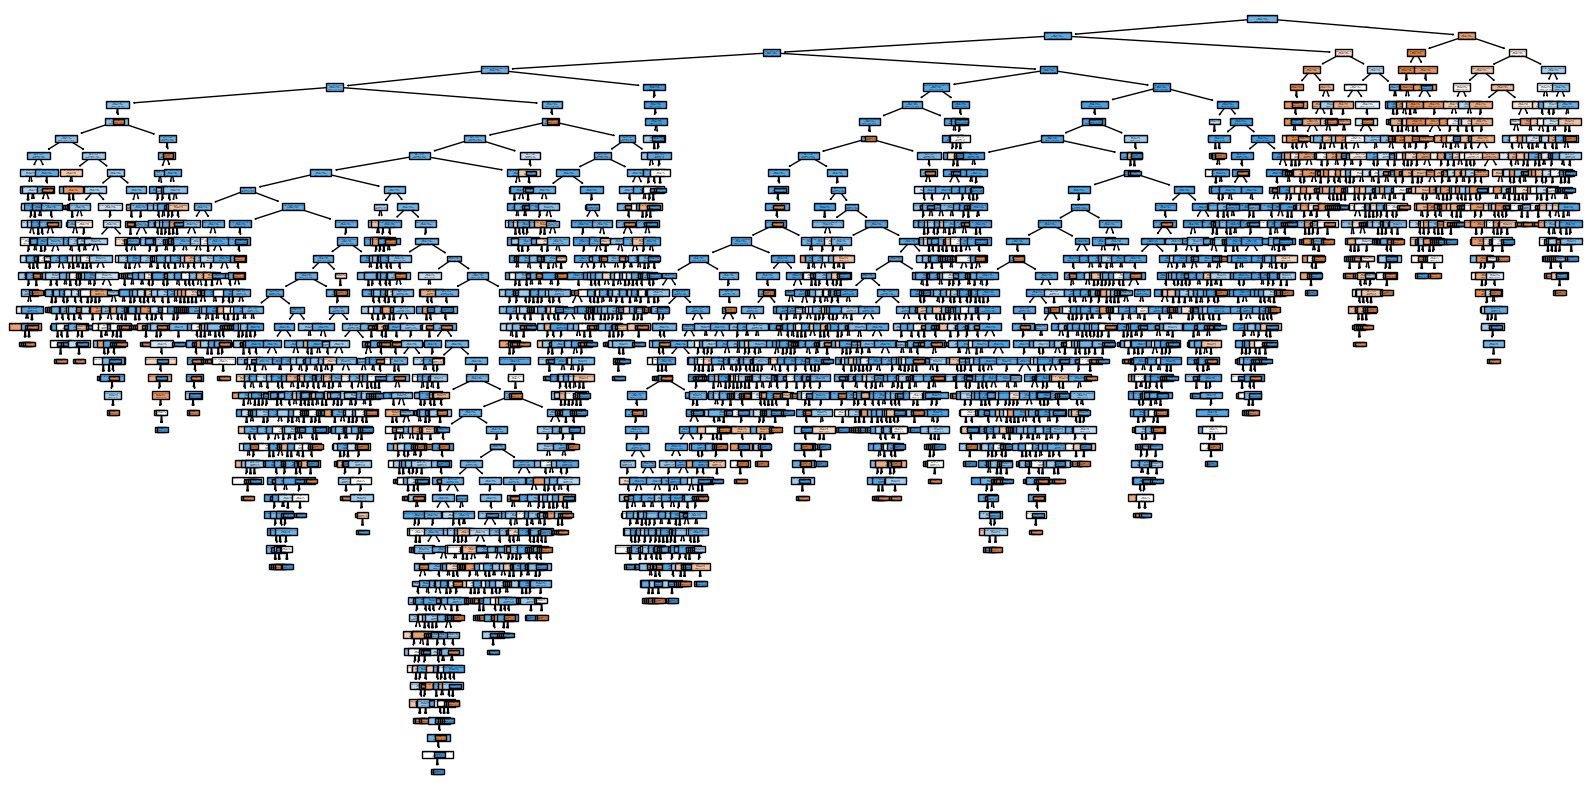

In [64]:
from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
tree.plot_tree(
    clf,
    feature_names=X.columns,
    filled=True
)
plt.show()

In [67]:
import pickle
with open("loan.pkl", "wb") as file:
    pickle.dump(clf, file)

print("Model saved successfully!")

Model saved successfully!


In [68]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test ,y_pred)
r2

-0.20943141355946304